In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "qqp"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 363846
    })
    validation: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 40430
    })
    test: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 390965
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['question1', 'question2', 'label', 'idx'],
    num_rows: 363846
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 363846
    })
    validation: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 40430
    })
    test: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 390965
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'question1': 'How is the life of a math student? Could you describe your own experiences?',
 'question2': 'Which level of prepration is enough for the exam jlpt5?',
 'label': 0,
 'idx': 0}

In [10]:
raw_train_dataset[5]['question1'], raw_train_dataset[5]['question2']

("How not to feel guilty since I am Muslim and I'm conscious we won't have sex together?",
 "I don't beleive I am bulimic, but I force throw up atleast once a day after I eat something and feel guilty. Should I tell somebody, and if so who?")

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'question1': Value('string'),
 'question2': Value('string'),
 'label': ClassLabel(names=['not_duplicate', 'duplicate']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["question1"], example["question2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['question1', 'question2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 363846
    })
    validation: Dataset({
        features: ['question1', 'question2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 40430
    })
    test: Dataset({
        features: ['question1', 'question2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 390965
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["question1", "question2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 62]),
 'token_type_ids': torch.Size([32, 62]),
 'attention_mask': torch.Size([32, 62])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7232, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda')

### Load Trained Weights

In [26]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [27]:
from train_eval_func import eval_loop

In [28]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9102151867425179, 'f1': 0.8799841301329101}

### Load Trained Weights for Model with 7 Layers

In [29]:
import os
from merge_helper import merge_bert_layers, LayerMergeTracker, apply_layer_tracking_to_model
from train_eval_func import train, get_primary_metric, set_lr_scheduler, get_recovery_epoch
from torch.optim import AdamW

In [30]:
model_7 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-7-{task_name}.pt', map_location=device)

In [32]:
model_7 = apply_layer_tracking_to_model(model_7, graft_state['layer_track'])

In [33]:
len(model_7.bert.encoder.layer)

7

In [34]:
model_7.to(device)
device

device(type='cuda')

In [35]:
model_7.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [36]:
eval_loop(model_7, val_dataloader, task_name, device)[0]

{'accuracy': 0.9040811278753401, 'f1': 0.870819453697535}

### Load Trained Weights for Model with 8 Layers

In [37]:
model_8 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-8-{task_name}.pt', map_location=device)

In [39]:
model_8 = apply_layer_tracking_to_model(model_8, graft_state['layer_track'])

In [40]:
len(model_8.bert.encoder.layer)

8

In [41]:
model_8.to(device)
device

device(type='cuda')

In [42]:
model_8.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [43]:
eval_loop(model_8, val_dataloader, task_name, device)[0]

{'accuracy': 0.9002968093000248, 'f1': 0.8716855005570587}

### Load Trained Weights for Model with 6 Layers

In [44]:
model_6 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [45]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-6-{task_name}.pt', map_location=device)

In [46]:
model_6 = apply_layer_tracking_to_model(model_6, graft_state['layer_track'])

In [47]:
len(model_6.bert.encoder.layer)

6

In [48]:
model_6.to(device)
device

device(type='cuda')

In [49]:
model_6.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [50]:
eval_loop(model_6, val_dataloader, task_name, device)[0]

{'accuracy': 0.9019539945584961, 'f1': 0.8677608753669602}

# 5. Pruning Study

In [51]:
analysis_save_path = f'./save_analysis/{task_name}'

### Masking 10 percent of amount

In [52]:
num_att_mask = int(12 * 12 * 0.1)
num_att_mask

14

In [53]:
num_int_mask = int(model.bert.encoder.layer[0].intermediate.dense.weight.shape[0] * 12 * 0.1)
num_int_mask

3686

## 5.1 Attention Heads

### 12 Layers

In [54]:
from structure_prune_helper import register_importance_masks, remove_importance_masks, iterativeMask, plot_results, plot_masking_comparison

In [55]:
register_importance_masks(model, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (12 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (12 heads)
  Layer 5: Registered masks (12 heads)
  Layer 6: Registered masks (12 heads)
  Layer 7: Registered masks (12 heads)
  Layer 8: Registered masks (12 heads)
  Layer 9: Registered masks (12 heads)
  Layer 10: Registered masks (12 heads)
  Layer 11: Registered masks (12 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [56]:
mask_history_head = iterativeMask(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
      accuracy: 0.9102
    ★ f1: 0.8800

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:23<00:00,  4.21it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 12, Remain: 12 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 12, Remain: 12 (100.0%)
Layer: 6, total: 12, Remain: 12 (100.0%)
Layer: 7, total: 12, Remain: 12 (100.0%)
Layer: 8, total: 12, Remain: 9 (75.0%)
Layer: 9, total: 12, Remain: 11 (91.67%)
Layer: 10, total: 12, Remain: 7 (58.33%)
Layer: 11, total: 12, Remain: 7 (58.33%)
  Metrics:
      accuracy: 0.9098
    ★ f1: 0.8799

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:19<00:00,  5.10it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 12, Remain: 11 (91.67%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 11 (91.67%)
Layer: 5, total: 12, Remain: 12 (100.0%)
Layer: 6, total: 12, Remain: 10 (83.33%)
Layer: 7, total: 12, Remain: 8 (66.67%)
Layer: 8, total: 12, Remain: 8 (66.67%)
Layer: 9, total: 12, Remain: 8 (66.67%)
Layer: 10, total: 12, Remain: 7 (58.33%)
Layer: 11, total: 12, Remain: 5 (41.67%)
  Metrics:
      accuracy: 0.9084
    ★ f1: 0.8789

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 2 (16.67%)
Layer: 1, total: 12, Remain: 4 (33.33%)
Layer: 2, total: 12, Remain: 5 (41.67%)
Layer: 3, total: 12, Remain: 6 (50.0%)
Layer: 4, total: 12, Remain: 3 (25.0%)
Layer: 5, total: 12, Remain: 6 (50.0%)
Layer: 6, total: 12, Remain: 4 (33.33%)
Layer: 7, total: 12, Remain: 3 (25.0%)
Layer: 8, total: 12, Remain: 4 (33.33%)
Layer: 9, total: 12, Remain: 3 (25.0%)
Layer: 10, total: 12, Remain: 3 (25.0%)
Layer: 11, total: 12, Remain: 3 (25.0%)
  Metrics:
      accuracy: 0.8679
    ★ f1: 0.8388

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:19<00:00,  5.03it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 2 (16.67%)
Layer: 1, total: 12, Remain: 2 (16.67%)
Layer: 2, total: 12, Remain: 3 (25.0%)
Layer: 3, total: 12, Remain: 4 (33.33%)
Layer: 4, total: 12, Remain: 2 (16.67%)
Layer: 5, total: 12, Remain: 5 (41.67%)
Layer: 6, total: 12, Remain: 2 (16.67%)
Layer: 7, total: 12, Remain: 1 (8.33%)
Layer: 8, total: 12, Remain: 4 (33.33%)
Layer: 9, total: 12, Remain: 3 (25.0%)
Layer: 10, total: 12, Remain: 1 (8.33%)
Layer: 11, total: 12, Remain: 3 (25.0%)
  Metrics:
      accuracy: 0.8145
    ★ f1: 0.7844

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:20<00:00,  4.89it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 0 (0.0%)
Layer: 1, total: 12, Remain: 1 (8.33%)
Layer: 2, total: 12, Remain: 3 (25.0%)
Layer: 3, total: 12, Remain: 3 (25.0%)
Layer: 4, total: 12, Remain: 1 (8.33%)
Layer: 5, total: 12, Remain: 5 (41.67%)
Layer: 6, total: 12, Remain: 1 (8.33%)
Layer: 7, total: 12, Remain: 0 (0.0%)
Layer: 8, total: 12, Remain: 2 (16.67%)
Layer: 9, total: 12, Remain: 2 (16.67%)
Layer: 10, total: 12, Remain: 0 (0.0%)
Layer: 11, total: 12, Remain: 0 (0.0%)
  Metrics:
      accuracy: 0.7292
    ★ f1: 0.6960


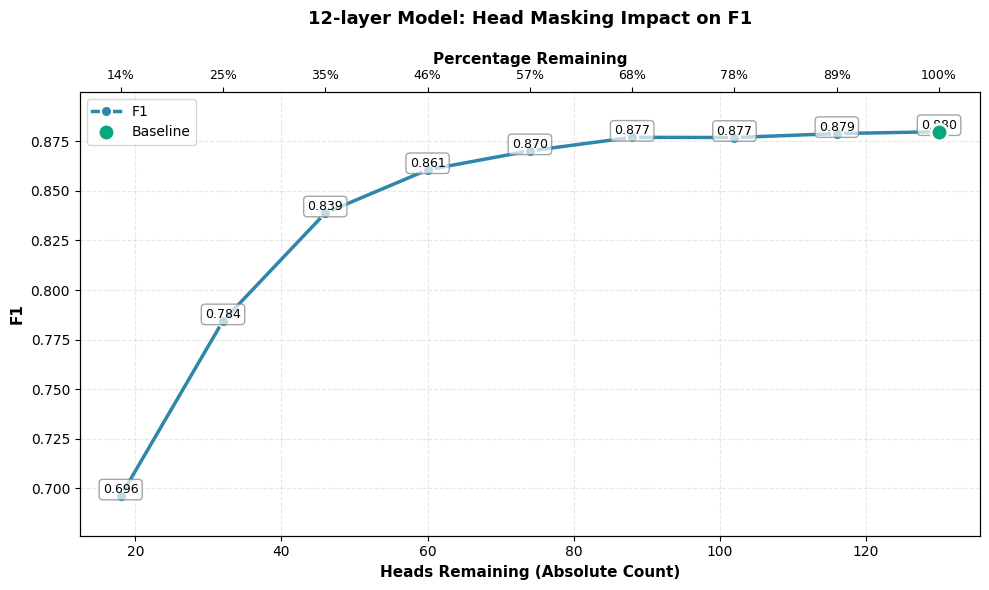

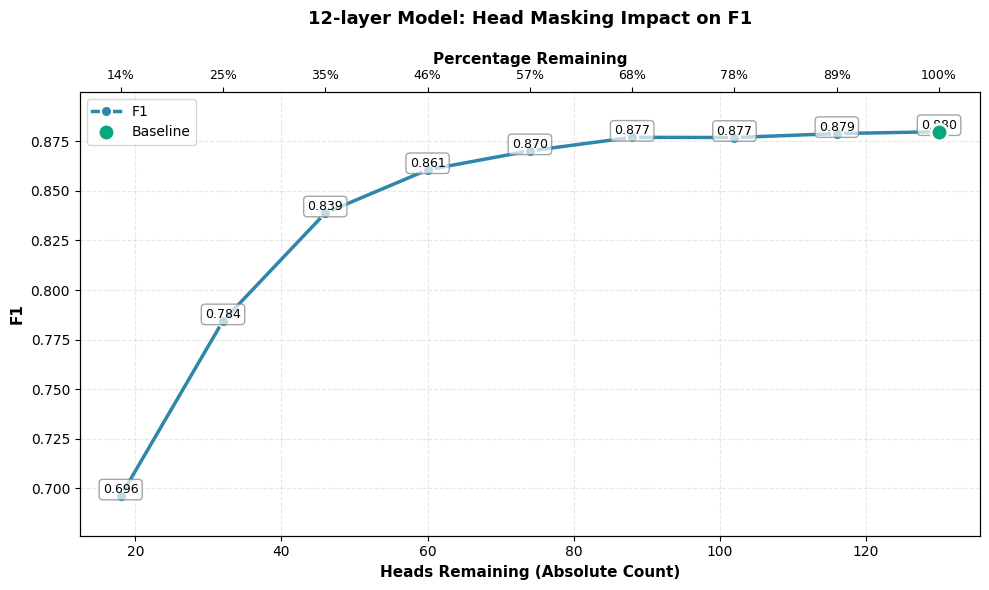

In [57]:
plot_results(
        mask_history_head,
        metric='f1',
        component='heads',
        title='12-layer Model: Head Masking Impact on F1'
)

In [58]:
remove_importance_masks(model, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [60]:
torch.save(mask_history_head, analysis_save_path + '/head.pt')

### 8 Layers

In [61]:
register_importance_masks(model_8, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (12 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (12 heads)
  Layer 5: Registered masks (36 heads)
  Layer 6: Registered masks (36 heads)
  Layer 7: Registered masks (12 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-4): 5 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [62]:
mask_history_head_8 = iterativeMask(
    model_8, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
      accuracy: 0.9003
    ★ f1: 0.8717

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:17<00:00,  5.72it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 12, Remain: 12 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 36, Remain: 36 (100.0%)
Layer: 6, total: 36, Remain: 23 (63.89%)
Layer: 7, total: 12, Remain: 11 (91.67%)
  Metrics:
      accuracy: 0.8984
    ★ f1: 0.8694

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:19<00:00,  5.02it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 12, Remain: 12 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 36, Remain: 30 (83.33%)
Layer: 6, total: 36, Remain: 18 (50.0%)
Layer: 7, total: 12, Remain: 8 (66.67%)
  Metrics:
      accuracy: 0.8976
    ★ f1: 0.8687

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 2 (16.67%)
Layer: 1, total: 12, Remain: 2 (16.67%)
Layer: 2, total: 12, Remain: 7 (58.33%)
Layer: 3, total: 12, Remain: 7 (58.33%)
Layer: 4, total: 12, Remain: 4 (33.33%)
Layer: 5, total: 36, Remain: 12 (33.33%)
Layer: 6, total: 36, Remain: 9 (25.0%)
Layer: 7, total: 12, Remain: 3 (25.0%)
  Metrics:
      accuracy: 0.8216
    ★ f1: 0.7977

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:17<00:00,  5.68it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 1 (8.33%)
Layer: 1, total: 12, Remain: 2 (16.67%)
Layer: 2, total: 12, Remain: 2 (16.67%)
Layer: 3, total: 12, Remain: 5 (41.67%)
Layer: 4, total: 12, Remain: 3 (25.0%)
Layer: 5, total: 36, Remain: 9 (25.0%)
Layer: 6, total: 36, Remain: 7 (19.44%)
Layer: 7, total: 12, Remain: 3 (25.0%)
  Metrics:
      accuracy: 0.7703
    ★ f1: 0.7490

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:19<00:00,  5.18it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 0 (0.0%)
Layer: 1, total: 12, Remain: 0 (0.0%)
Layer: 2, total: 12, Remain: 1 (8.33%)
Layer: 3, total: 12, Remain: 3 (25.0%)
Layer: 4, total: 12, Remain: 1 (8.33%)
Layer: 5, total: 36, Remain: 5 (13.89%)
Layer: 6, total: 36, Remain: 6 (16.67%)
Layer: 7, total: 12, Remain: 2 (16.67%)
  Metrics:
      accuracy: 0.7063
    ★ f1: 0.6891


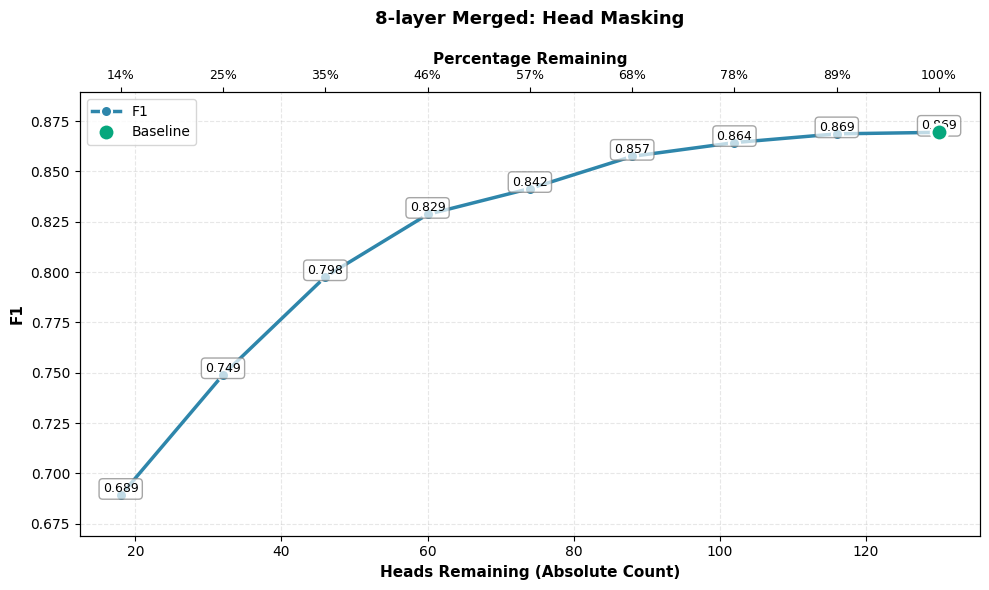

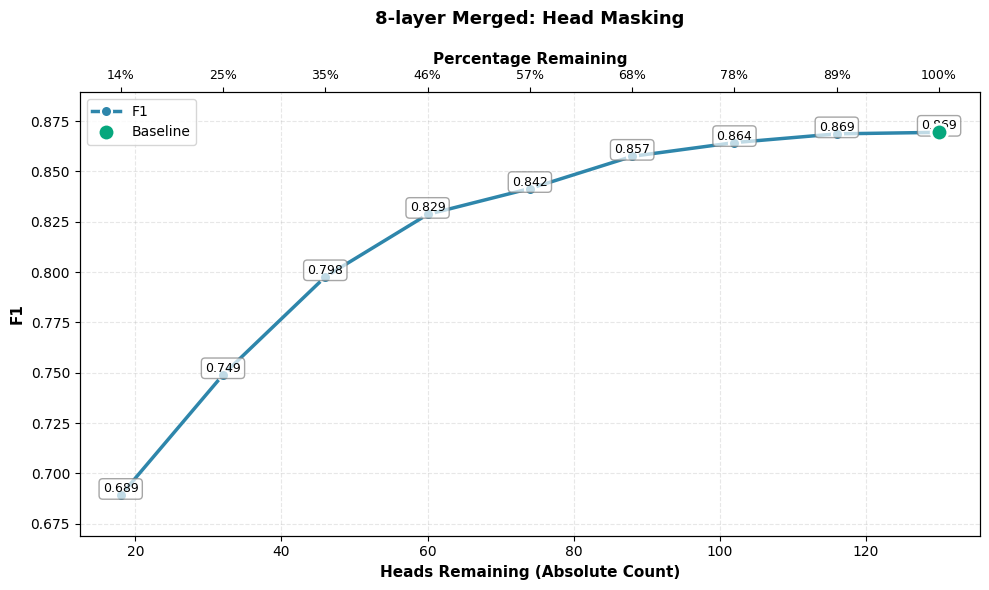

In [63]:
plot_results(
        mask_history_head_8,
        metric='f1',
        component='heads',
        title='8-layer Merged: Head Masking'
)

In [64]:
remove_importance_masks(model_8, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [65]:
torch.save(mask_history_head_8, analysis_save_path + '/head_8.pt')

### 7 Layers

In [66]:
register_importance_masks(model_7, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (24 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (36 heads)
  Layer 5: Registered masks (36 heads)
  Layer 6: Registered masks (12 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [67]:
mask_history_head_7 = iterativeMask(
    model_7, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
      accuracy: 0.9041
    ★ f1: 0.8708

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:17<00:00,  5.67it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 36, Remain: 31 (86.11%)
Layer: 5, total: 36, Remain: 28 (77.78%)
Layer: 6, total: 12, Remain: 11 (91.67%)
  Metrics:
      accuracy: 0.9038
    ★ f1: 0.8708

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:17<00:00,  5.80it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 36, Remain: 27 (75.0%)
Layer: 5, total: 36, Remain: 20 (55.56%)
Layer: 6, total: 12, Remain: 9 (75.0%)
  Metrics:
      accuracy: 0.9011
    ★ f1: 0.8664

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 4 (33.33%)
Layer: 1, total: 24, Remain: 8 (33.33%)
Layer: 2, total: 12, Remain: 9 (75.0%)
Layer: 3, total: 12, Remain: 6 (50.0%)
Layer: 4, total: 36, Remain: 8 (22.22%)
Layer: 5, total: 36, Remain: 7 (19.44%)
Layer: 6, total: 12, Remain: 4 (33.33%)
  Metrics:
      accuracy: 0.8641
    ★ f1: 0.8280

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:17<00:00,  5.74it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 3 (25.0%)
Layer: 1, total: 24, Remain: 4 (16.67%)
Layer: 2, total: 12, Remain: 6 (50.0%)
Layer: 3, total: 12, Remain: 4 (33.33%)
Layer: 4, total: 36, Remain: 7 (19.44%)
Layer: 5, total: 36, Remain: 6 (16.67%)
Layer: 6, total: 12, Remain: 2 (16.67%)
  Metrics:
      accuracy: 0.8244
    ★ f1: 0.7785

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:16<00:00,  5.90it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 1 (8.33%)
Layer: 1, total: 24, Remain: 3 (12.5%)
Layer: 2, total: 12, Remain: 3 (25.0%)
Layer: 3, total: 12, Remain: 1 (8.33%)
Layer: 4, total: 36, Remain: 2 (5.56%)
Layer: 5, total: 36, Remain: 6 (16.67%)
Layer: 6, total: 12, Remain: 2 (16.67%)
  Metrics:
      accuracy: 0.7599
    ★ f1: 0.6744


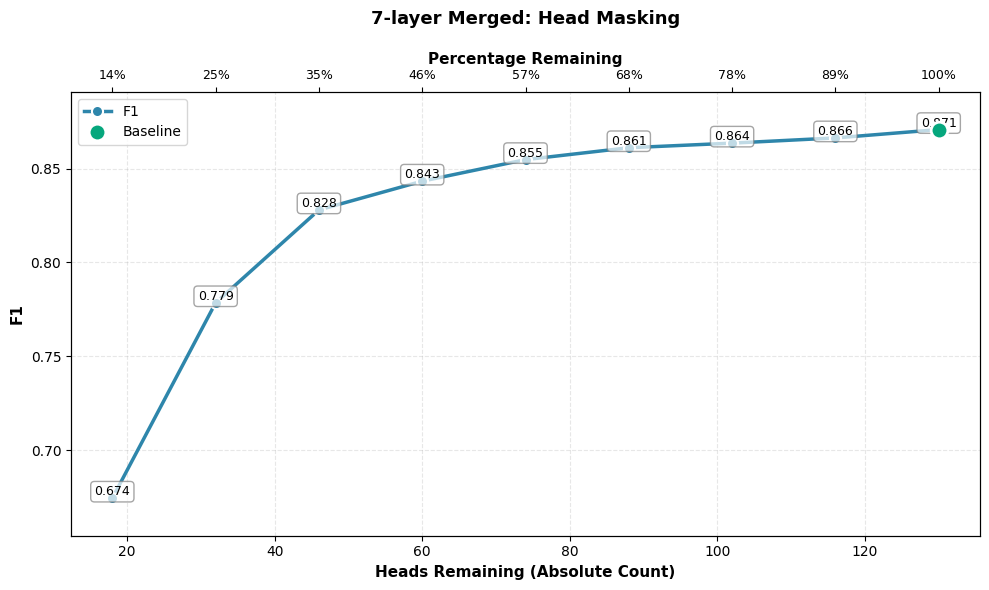

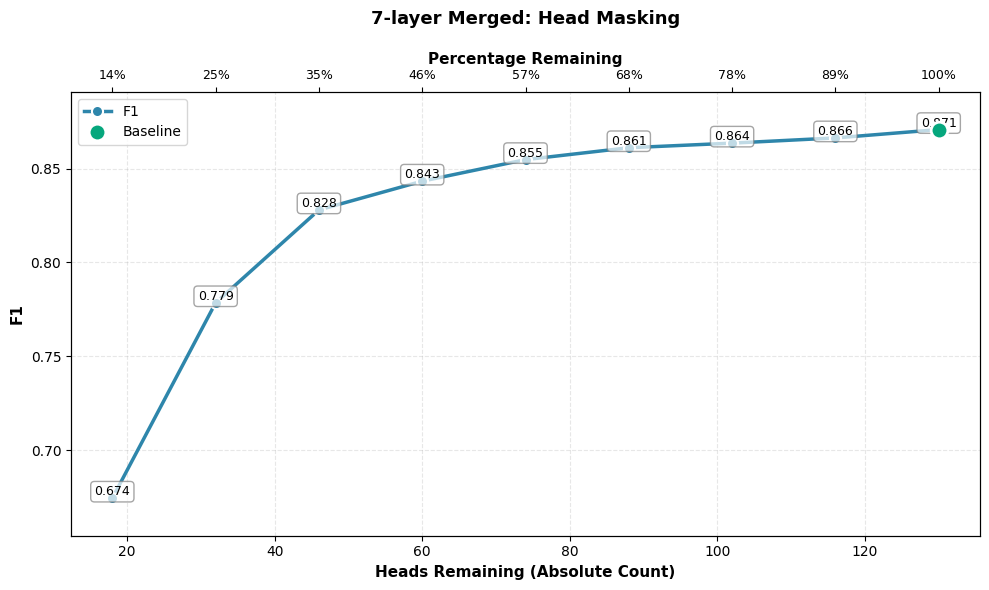

In [68]:
plot_results(
        mask_history_head_7,
        metric='f1',
        component='heads',
        title='7-layer Merged: Head Masking'
)

In [69]:
remove_importance_masks(model_7, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [70]:
torch.save(mask_history_head_7, analysis_save_path + '/head_7.pt')

### 6 Layers

In [71]:
register_importance_masks(model_6, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (24 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (36 heads)
  Layer 5: Registered masks (48 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [72]:
mask_history_head_6 = iterativeMask(
    model_6, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
      accuracy: 0.9020
    ★ f1: 0.8678

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:17<00:00,  5.74it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 36, Remain: 34 (94.44%)
Layer: 5, total: 48, Remain: 36 (75.0%)
  Metrics:
      accuracy: 0.8998
    ★ f1: 0.8661

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:17<00:00,  5.80it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 36, Remain: 29 (80.56%)
Layer: 5, total: 48, Remain: 27 (56.25%)
  Metrics:
      accuracy: 0.8995
    ★ f1: 0.8666

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 5 (41.67%)
Layer: 1, total: 24, Remain: 7 (29.17%)
Layer: 2, total: 12, Remain: 8 (66.67%)
Layer: 3, total: 12, Remain: 7 (58.33%)
Layer: 4, total: 36, Remain: 11 (30.56%)
Layer: 5, total: 48, Remain: 8 (16.67%)
  Metrics:
      accuracy: 0.8685
    ★ f1: 0.8238

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:17<00:00,  5.61it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 2 (16.67%)
Layer: 1, total: 24, Remain: 6 (25.0%)
Layer: 2, total: 12, Remain: 7 (58.33%)
Layer: 3, total: 12, Remain: 5 (41.67%)
Layer: 4, total: 36, Remain: 7 (19.44%)
Layer: 5, total: 48, Remain: 5 (10.42%)
  Metrics:
      accuracy: 0.8363
    ★ f1: 0.7850

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:17<00:00,  5.79it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 0 (0.0%)
Layer: 1, total: 24, Remain: 4 (16.67%)
Layer: 2, total: 12, Remain: 2 (16.67%)
Layer: 3, total: 12, Remain: 3 (25.0%)
Layer: 4, total: 36, Remain: 4 (11.11%)
Layer: 5, total: 48, Remain: 5 (10.42%)
  Metrics:
      accuracy: 0.7800
    ★ f1: 0.6872


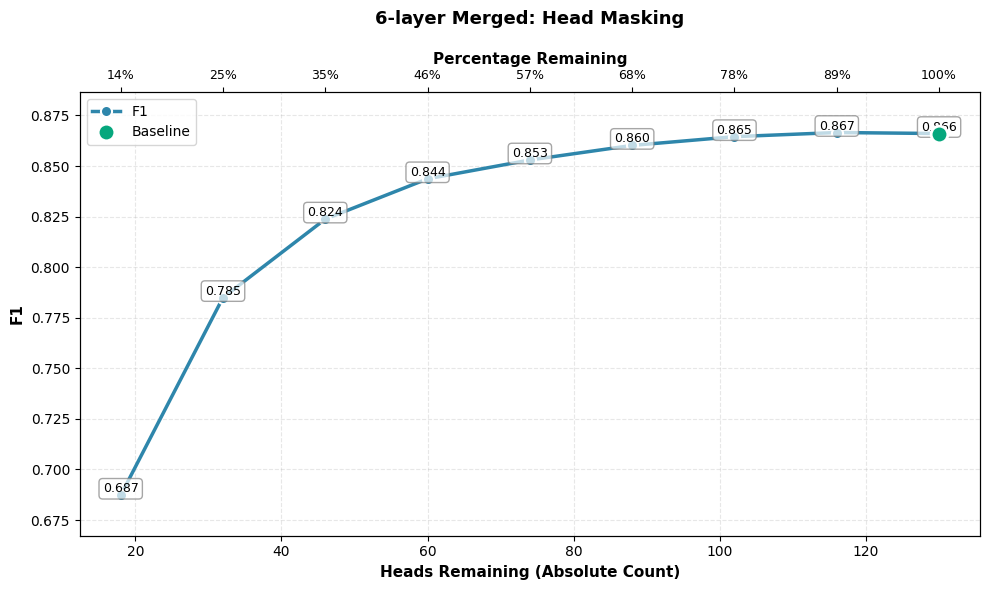

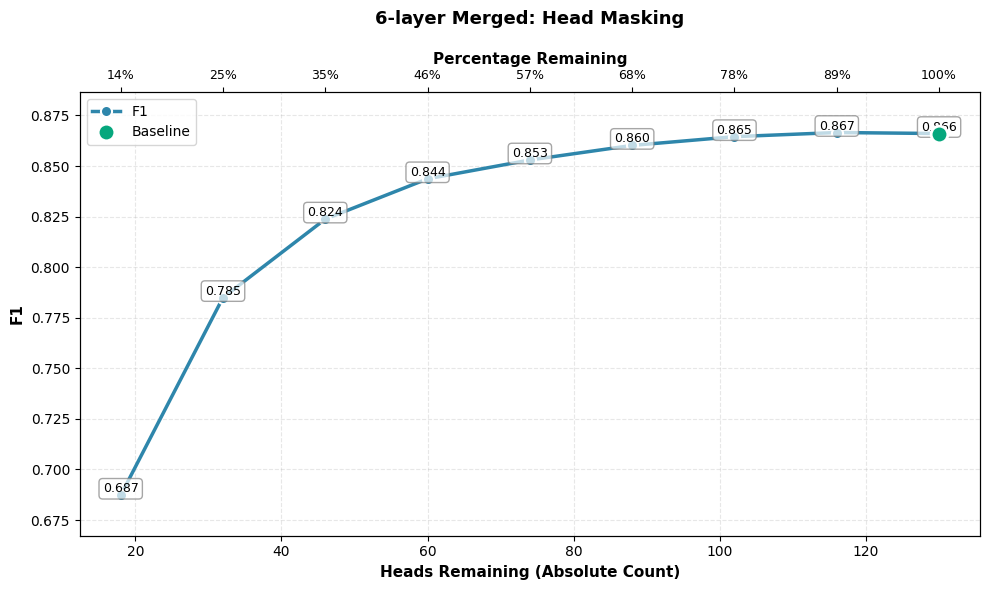

In [73]:
plot_results(
        mask_history_head_6,
        metric='f1',
        component='heads',
        title='6-layer Merged: Head Masking'
)

In [74]:
remove_importance_masks(model_6, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [75]:
torch.save(mask_history_head_6, analysis_save_path + '/head_6.pt')

### Comparision Plot

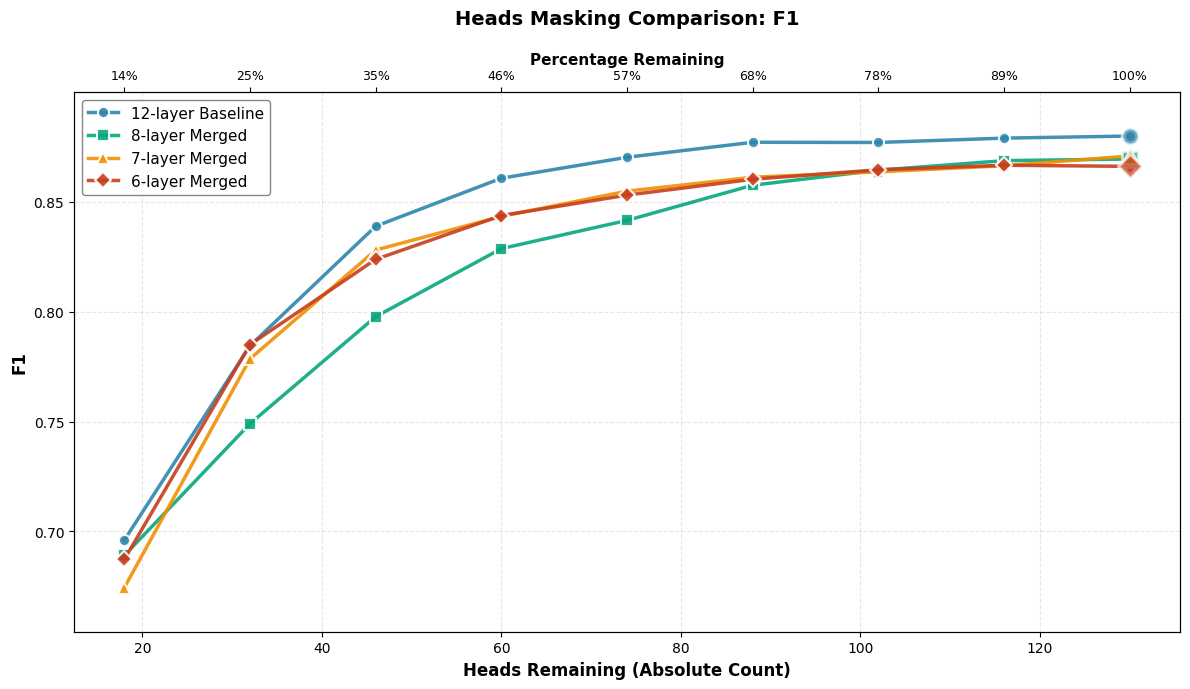

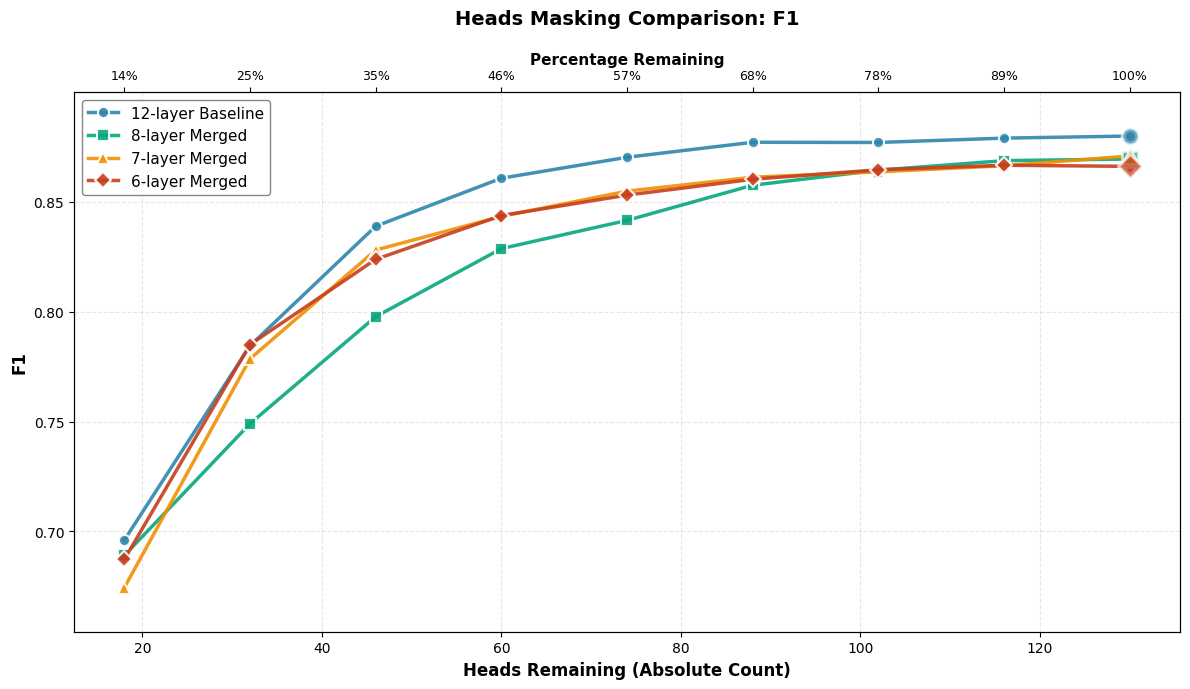

In [76]:
plot_masking_comparison(
    [mask_history_head, mask_history_head_8, mask_history_head_7, mask_history_head_6], 
    labels=['12-layer Baseline', '8-layer Merged', '7-layer Merged', '6-layer Merged'],
    metric='f1', component='heads'
)

## 5.2 FFN Neurons

### 12 Layers

In [77]:
register_importance_masks(model, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (3072 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (3072 neurons)
  Layer 6: Registered masks (3072 neurons)
  Layer 7: Registered masks (3072 neurons)
  Layer 8: Registered masks (3072 neurons)
  Layer 9: Registered masks (3072 neurons)
  Layer 10: Registered masks (3072 neurons)
  Layer 11: Registered masks (3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [78]:
mask_history_neuron = iterativeMask(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
      accuracy: 0.9102
    ★ f1: 0.8800

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.95it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3067 (99.84%)
Layer: 1, total: 3072, Remain: 3069 (99.9%)
Layer: 2, total: 3072, Remain: 3071 (99.97%)
Layer: 3, total: 3072, Remain: 3069 (99.9%)
Layer: 4, total: 3072, Remain: 3072 (100.0%)
Layer: 5, total: 3072, Remain: 3072 (100.0%)
Layer: 6, total: 3072, Remain: 3071 (99.97%)
Layer: 7, total: 3072, Remain: 3071 (99.97%)
Layer: 8, total: 3072, Remain: 3071 (99.97%)
Layer: 9, total: 3072, Remain: 2996 (97.53%)
Layer: 10, total: 3072, Remain: 2082 (67.77%)
Layer: 11, total: 3072, Remain: 467 (15.2%)
  Metrics:
      accuracy: 0.9099
    ★ f1: 0.8794

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:18<00:00,  5.45it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3041 (98.99%)
Layer: 1, total: 3072, Remain: 3052 (99.35%)
Layer: 2, total: 3072, Remain: 3066 (99.8%)
Layer: 3, total: 3072, Remain: 3065 (99.77%)
Layer: 4, total: 3072, Remain: 3061 (99.64%)
Layer: 5, total: 3072, Remain: 3053 (99.38%)
Layer: 6, total: 3072, Remain: 3061 (99.64%)
Layer: 7, total: 3072, Remain: 3043 (99.06%)
Layer: 8, total: 3072, Remain: 2871 (93.46%)
Layer: 9, total: 3072, Remain: 1637 (53.29%)
Layer: 10, total: 3072, Remain: 427 (13.9%)
Layer: 11, total: 3072, Remain: 115 (3.74%)
  Metrics:
      accuracy: 0.9096
    ★ f1: 0.8789

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1127 (36.69%)
Layer: 1, total: 3072, Remain: 1235 (40.2%)
Layer: 2, total: 3072, Remain: 1382 (44.99%)
Layer: 3, total: 3072, Remain: 1601 (52.12%)
Layer: 4, total: 3072, Remain: 1538 (50.07%)
Layer: 5, total: 3072, Remain: 1428 (46.48%)
Layer: 6, total: 3072, Remain: 1229 (40.01%)
Layer: 7, total: 3072, Remain: 934 (30.4%)
Layer: 8, total: 3072, Remain: 441 (14.36%)
Layer: 9, total: 3072, Remain: 93 (3.03%)
Layer: 10, total: 3072, Remain: 38 (1.24%)
Layer: 11, total: 3072, Remain: 16 (0.52%)
  Metrics:
      accuracy: 0.8841
    ★ f1: 0.8411

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:19<00:00,  5.02it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 963 (31.35%)
Layer: 1, total: 3072, Remain: 994 (32.36%)
Layer: 2, total: 3072, Remain: 970 (31.58%)
Layer: 3, total: 3072, Remain: 1067 (34.73%)
Layer: 4, total: 3072, Remain: 933 (30.37%)
Layer: 5, total: 3072, Remain: 855 (27.83%)
Layer: 6, total: 3072, Remain: 699 (22.75%)
Layer: 7, total: 3072, Remain: 520 (16.93%)
Layer: 8, total: 3072, Remain: 258 (8.4%)
Layer: 9, total: 3072, Remain: 70 (2.28%)
Layer: 10, total: 3072, Remain: 33 (1.07%)
Layer: 11, total: 3072, Remain: 14 (0.46%)
  Metrics:
      accuracy: 0.8665
    ★ f1: 0.8182

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:18<00:00,  5.52it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 637 (20.74%)
Layer: 1, total: 3072, Remain: 577 (18.78%)
Layer: 2, total: 3072, Remain: 452 (14.71%)
Layer: 3, total: 3072, Remain: 452 (14.71%)
Layer: 4, total: 3072, Remain: 421 (13.7%)
Layer: 5, total: 3072, Remain: 358 (11.65%)
Layer: 6, total: 3072, Remain: 299 (9.73%)
Layer: 7, total: 3072, Remain: 275 (8.95%)
Layer: 8, total: 3072, Remain: 123 (4.0%)
Layer: 9, total: 3072, Remain: 53 (1.73%)
Layer: 10, total: 3072, Remain: 31 (1.01%)
Layer: 11, total: 3072, Remain: 12 (0.39%)
  Metrics:
      accuracy: 0.8294
    ★ f1: 0.7757


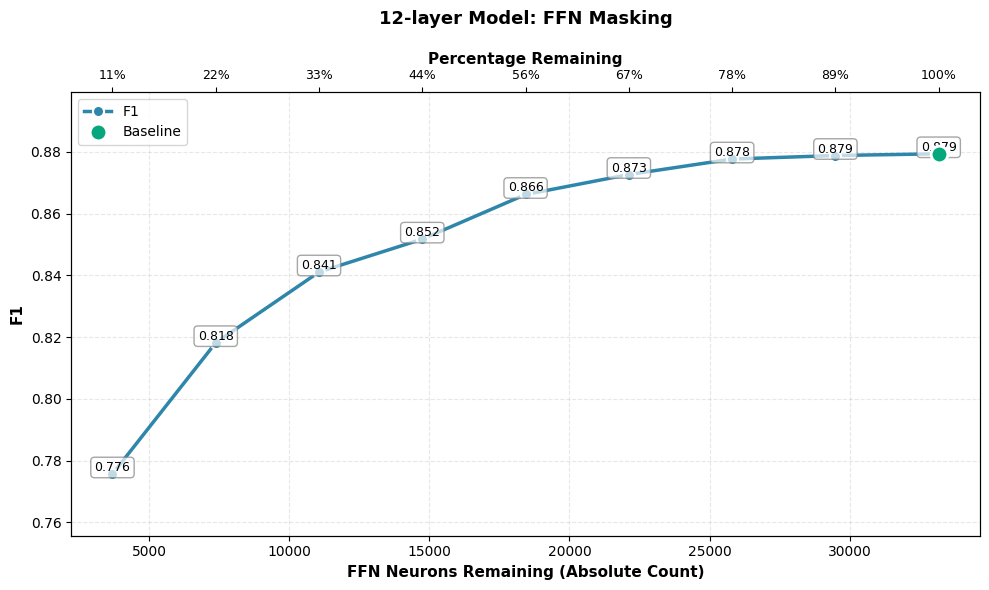

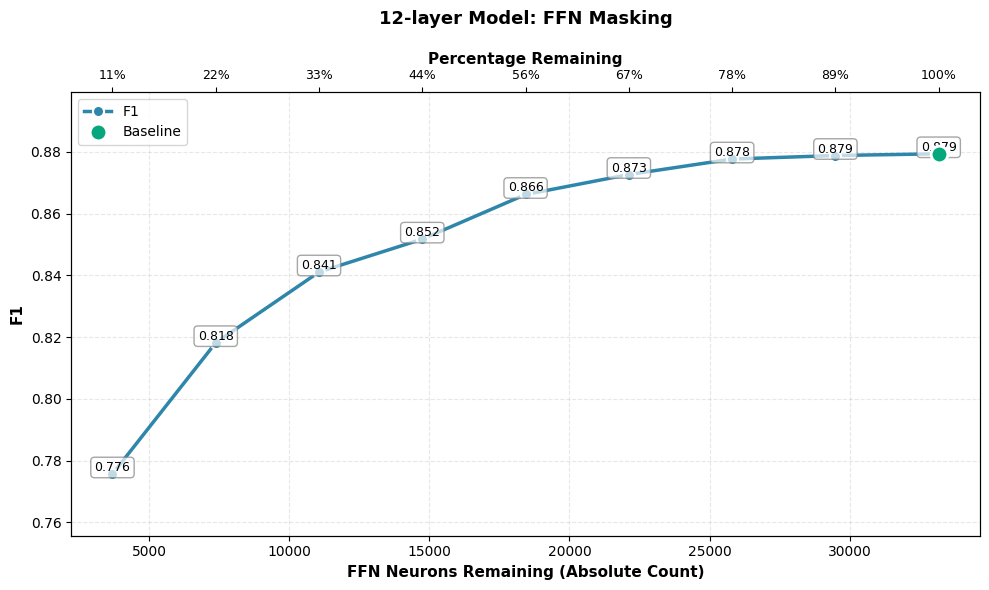

In [79]:
plot_results(mask_history_neuron, metric='f1', component='ffn', title='12-layer Model: FFN Masking')

In [80]:
remove_importance_masks(model, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [81]:
torch.save(mask_history_neuron, analysis_save_path + '/neuron.pt')

### 8 Layers

In [82]:
register_importance_masks(model_8, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (3072 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (9216 neurons)
  Layer 6: Registered masks (9216 neurons)
  Layer 7: Registered masks (3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-4): 5 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [83]:
mask_history_neuron_8 = iterativeMask(
    model_8, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
      accuracy: 0.9003
    ★ f1: 0.8717

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.88it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3066 (99.8%)
Layer: 1, total: 3072, Remain: 3067 (99.84%)
Layer: 2, total: 3072, Remain: 3071 (99.97%)
Layer: 3, total: 3072, Remain: 3070 (99.93%)
Layer: 4, total: 3072, Remain: 3072 (100.0%)
Layer: 5, total: 9216, Remain: 9214 (99.98%)
Layer: 6, total: 9216, Remain: 8058 (87.43%)
Layer: 7, total: 3072, Remain: 560 (18.23%)
  Metrics:
      accuracy: 0.9001
    ★ f1: 0.8714

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:17<00:00,  5.57it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3060 (99.61%)
Layer: 1, total: 3072, Remain: 3063 (99.71%)
Layer: 2, total: 3072, Remain: 3068 (99.87%)
Layer: 3, total: 3072, Remain: 3068 (99.87%)
Layer: 4, total: 3072, Remain: 3072 (100.0%)
Layer: 5, total: 9216, Remain: 9177 (99.58%)
Layer: 6, total: 9216, Remain: 4728 (51.3%)
Layer: 7, total: 3072, Remain: 256 (8.33%)
  Metrics:
      accuracy: 0.8996
    ★ f1: 0.8708

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1166 (37.96%)
Layer: 1, total: 3072, Remain: 1280 (41.67%)
Layer: 2, total: 3072, Remain: 1547 (50.36%)
Layer: 3, total: 3072, Remain: 1837 (59.8%)
Layer: 4, total: 3072, Remain: 1978 (64.39%)
Layer: 5, total: 9216, Remain: 2955 (32.06%)
Layer: 6, total: 9216, Remain: 279 (3.03%)
Layer: 7, total: 3072, Remain: 20 (0.65%)
  Metrics:
      accuracy: 0.8725
    ★ f1: 0.8287

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:17<00:00,  5.63it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 881 (28.68%)
Layer: 1, total: 3072, Remain: 911 (29.65%)
Layer: 2, total: 3072, Remain: 973 (31.67%)
Layer: 3, total: 3072, Remain: 1110 (36.13%)
Layer: 4, total: 3072, Remain: 1300 (42.32%)
Layer: 5, total: 9216, Remain: 1975 (21.43%)
Layer: 6, total: 9216, Remain: 208 (2.26%)
Layer: 7, total: 3072, Remain: 18 (0.59%)
  Metrics:
      accuracy: 0.8525
    ★ f1: 0.8061

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.92it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 559 (18.2%)
Layer: 1, total: 3072, Remain: 500 (16.28%)
Layer: 2, total: 3072, Remain: 428 (13.93%)
Layer: 3, total: 3072, Remain: 461 (15.01%)
Layer: 4, total: 3072, Remain: 525 (17.09%)
Layer: 5, total: 9216, Remain: 1054 (11.44%)
Layer: 6, total: 9216, Remain: 149 (1.62%)
Layer: 7, total: 3072, Remain: 14 (0.46%)
  Metrics:
      accuracy: 0.8141
    ★ f1: 0.7733


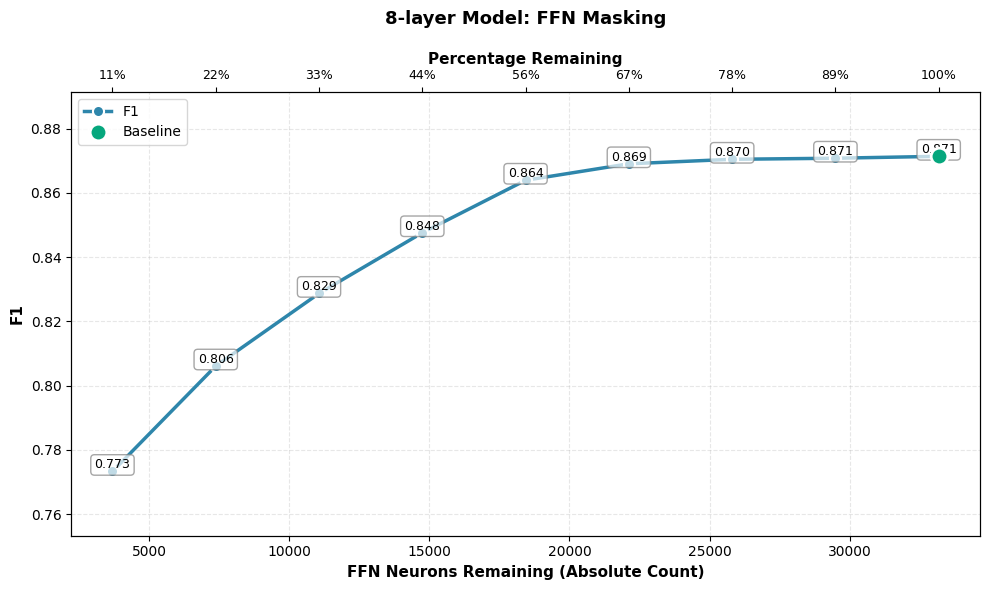

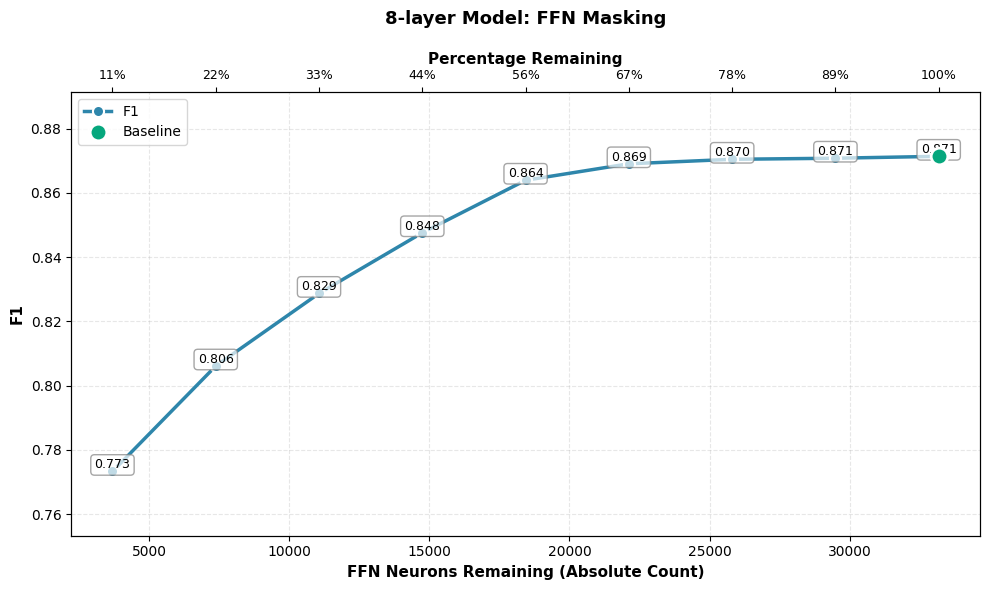

In [84]:
plot_results(mask_history_neuron_8, metric='f1', component='ffn', title='8-layer Model: FFN Masking')

In [85]:
remove_importance_masks(model_8, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [86]:
torch.save(mask_history_neuron_8, analysis_save_path + '/neuron_8.pt')

### 7 Layers

In [87]:
register_importance_masks(model_7, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (6144 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (9216 neurons)
  Layer 5: Registered masks (9216 neurons)
  Layer 6: Registered masks (3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [88]:
mask_history_neuron_7 = iterativeMask(
    model_7, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
      accuracy: 0.9041
    ★ f1: 0.8708

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:17<00:00,  5.65it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3067 (99.84%)
Layer: 1, total: 6144, Remain: 6141 (99.95%)
Layer: 2, total: 3072, Remain: 3071 (99.97%)
Layer: 3, total: 3072, Remain: 3072 (100.0%)
Layer: 4, total: 9216, Remain: 9210 (99.93%)
Layer: 5, total: 9216, Remain: 8084 (87.72%)
Layer: 6, total: 3072, Remain: 533 (17.35%)
  Metrics:
      accuracy: 0.9040
    ★ f1: 0.8706

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:18<00:00,  5.54it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3065 (99.77%)
Layer: 1, total: 6144, Remain: 6138 (99.9%)
Layer: 2, total: 3072, Remain: 3068 (99.87%)
Layer: 3, total: 3072, Remain: 3070 (99.93%)
Layer: 4, total: 9216, Remain: 9157 (99.36%)
Layer: 5, total: 9216, Remain: 4766 (51.71%)
Layer: 6, total: 3072, Remain: 228 (7.42%)
  Metrics:
      accuracy: 0.9037
    ★ f1: 0.8705

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1416 (46.09%)
Layer: 1, total: 6144, Remain: 2689 (43.77%)
Layer: 2, total: 3072, Remain: 1976 (64.32%)
Layer: 3, total: 3072, Remain: 1998 (65.04%)
Layer: 4, total: 9216, Remain: 2688 (29.17%)
Layer: 5, total: 9216, Remain: 278 (3.02%)
Layer: 6, total: 3072, Remain: 17 (0.55%)
  Metrics:
      accuracy: 0.8799
    ★ f1: 0.8318

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:19<00:00,  5.17it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 993 (32.32%)
Layer: 1, total: 6144, Remain: 1813 (29.51%)
Layer: 2, total: 3072, Remain: 1186 (38.61%)
Layer: 3, total: 3072, Remain: 1329 (43.26%)
Layer: 4, total: 9216, Remain: 1820 (19.75%)
Layer: 5, total: 9216, Remain: 221 (2.4%)
Layer: 6, total: 3072, Remain: 14 (0.46%)
  Metrics:
      accuracy: 0.8636
    ★ f1: 0.8131

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:17<00:00,  5.78it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 650 (21.16%)
Layer: 1, total: 6144, Remain: 930 (15.14%)
Layer: 2, total: 3072, Remain: 475 (15.46%)
Layer: 3, total: 3072, Remain: 551 (17.94%)
Layer: 4, total: 9216, Remain: 922 (10.0%)
Layer: 5, total: 9216, Remain: 149 (1.62%)
Layer: 6, total: 3072, Remain: 13 (0.42%)
  Metrics:
      accuracy: 0.8326
    ★ f1: 0.7782


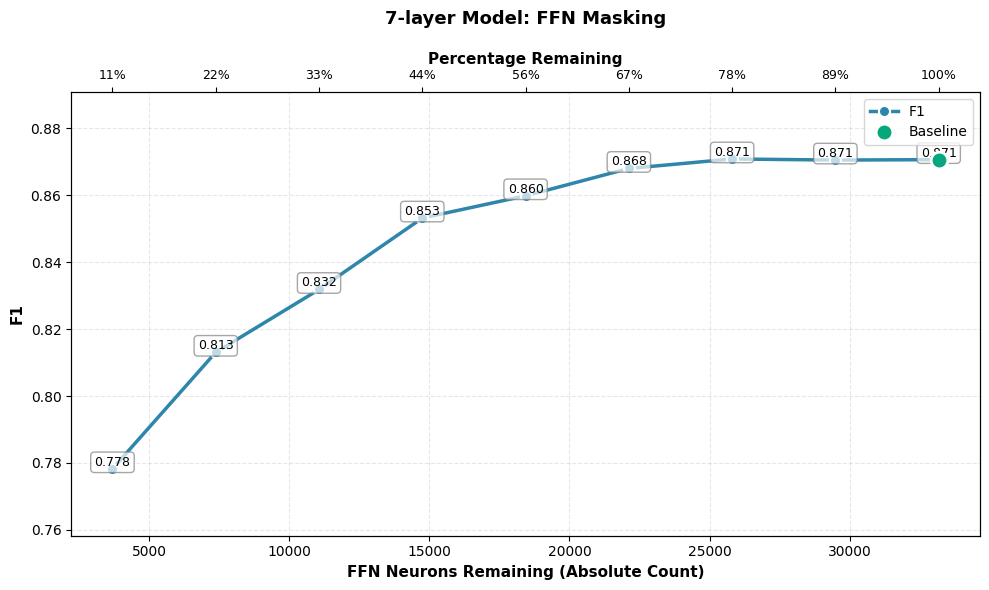

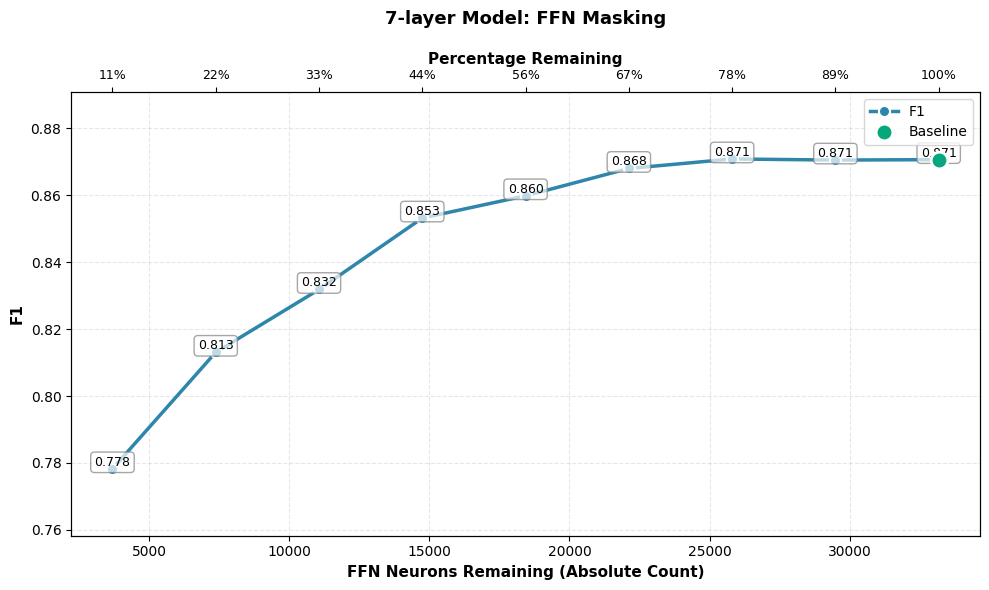

In [89]:
plot_results(mask_history_neuron_7, metric='f1', component='ffn', title='7-layer Model: FFN Masking')

In [90]:
remove_importance_masks(model_7, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [91]:
torch.save(mask_history_neuron_7, analysis_save_path + '/neuron_7.pt')

### 6 Layers

In [92]:
register_importance_masks(model_6, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (6144 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (9216 neurons)
  Layer 5: Registered masks (12288 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [93]:
mask_history_neuron_6 = iterativeMask(
    model_6, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
      accuracy: 0.9020
    ★ f1: 0.8678

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:17<00:00,  5.67it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3070 (99.93%)
Layer: 1, total: 6144, Remain: 6142 (99.97%)
Layer: 2, total: 3072, Remain: 3072 (100.0%)
Layer: 3, total: 3072, Remain: 3072 (100.0%)
Layer: 4, total: 9216, Remain: 9215 (99.99%)
Layer: 5, total: 12288, Remain: 8607 (70.04%)
  Metrics:
      accuracy: 0.9019
    ★ f1: 0.8677

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:17<00:00,  5.74it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3068 (99.87%)
Layer: 1, total: 6144, Remain: 6141 (99.95%)
Layer: 2, total: 3072, Remain: 3071 (99.97%)
Layer: 3, total: 3072, Remain: 3072 (100.0%)
Layer: 4, total: 9216, Remain: 9207 (99.9%)
Layer: 5, total: 12288, Remain: 4933 (40.14%)
  Metrics:
      accuracy: 0.9020
    ★ f1: 0.8680

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1636 (53.26%)
Layer: 1, total: 6144, Remain: 2854 (46.45%)
Layer: 2, total: 3072, Remain: 2079 (67.68%)
Layer: 3, total: 3072, Remain: 2007 (65.33%)
Layer: 4, total: 9216, Remain: 2291 (24.86%)
Layer: 5, total: 12288, Remain: 195 (1.59%)
  Metrics:
      accuracy: 0.8819
    ★ f1: 0.8313

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:17<00:00,  5.72it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1044 (33.98%)
Layer: 1, total: 6144, Remain: 1832 (29.82%)
Layer: 2, total: 3072, Remain: 1326 (43.16%)
Layer: 3, total: 3072, Remain: 1375 (44.76%)
Layer: 4, total: 9216, Remain: 1661 (18.02%)
Layer: 5, total: 12288, Remain: 138 (1.12%)
  Metrics:
      accuracy: 0.8642
    ★ f1: 0.8068

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.94it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 726 (23.63%)
Layer: 1, total: 6144, Remain: 958 (15.59%)
Layer: 2, total: 3072, Remain: 498 (16.21%)
Layer: 3, total: 3072, Remain: 570 (18.55%)
Layer: 4, total: 9216, Remain: 841 (9.13%)
Layer: 5, total: 12288, Remain: 97 (0.79%)
  Metrics:
      accuracy: 0.8397
    ★ f1: 0.7862


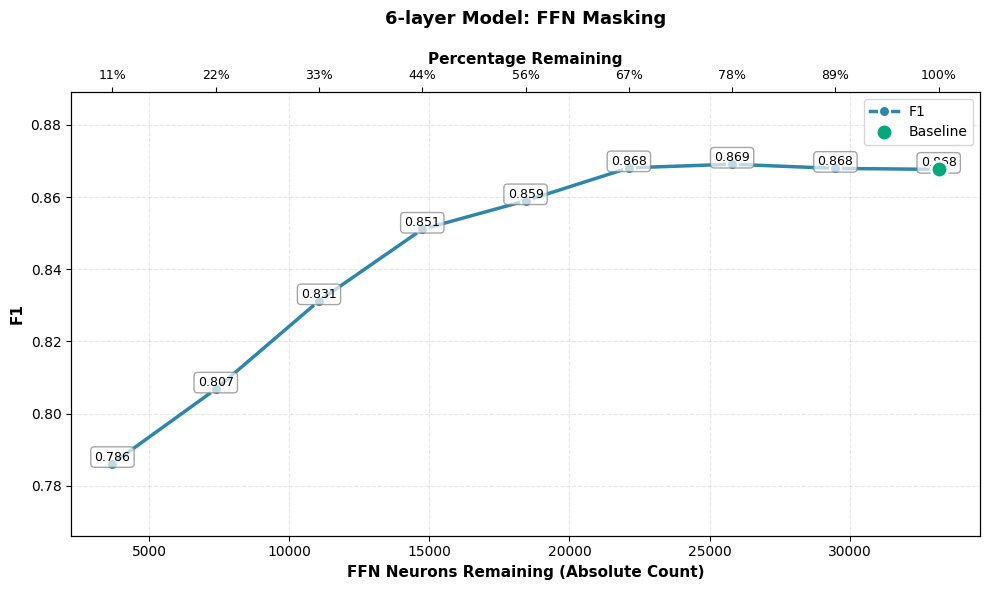

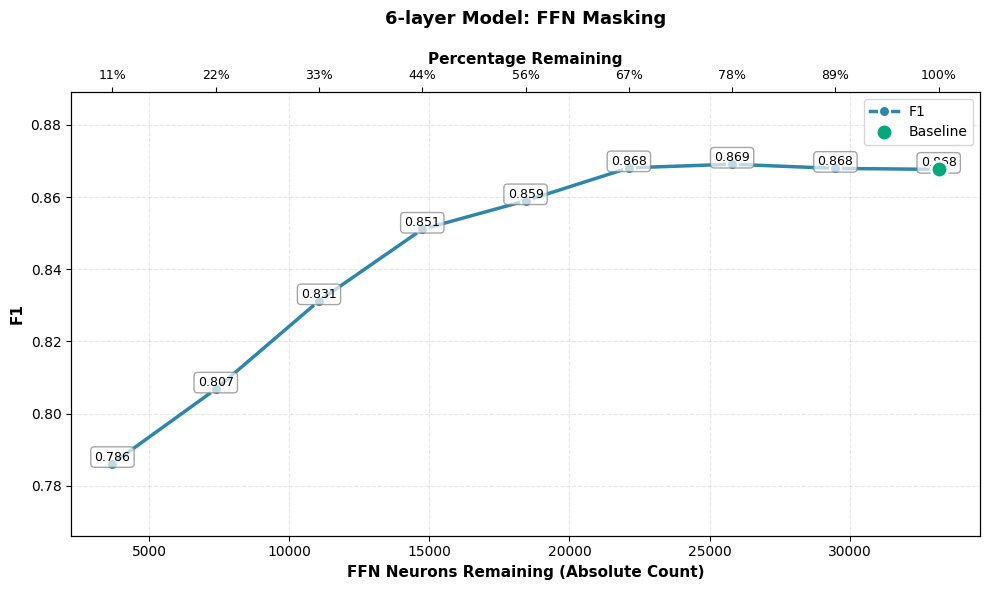

In [94]:
plot_results(mask_history_neuron_6, metric='f1', component='ffn', title='6-layer Model: FFN Masking')

In [95]:
remove_importance_masks(model_6, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [96]:
torch.save(mask_history_neuron_6, analysis_save_path + '/neuron_6.pt')

### Plot Comparision

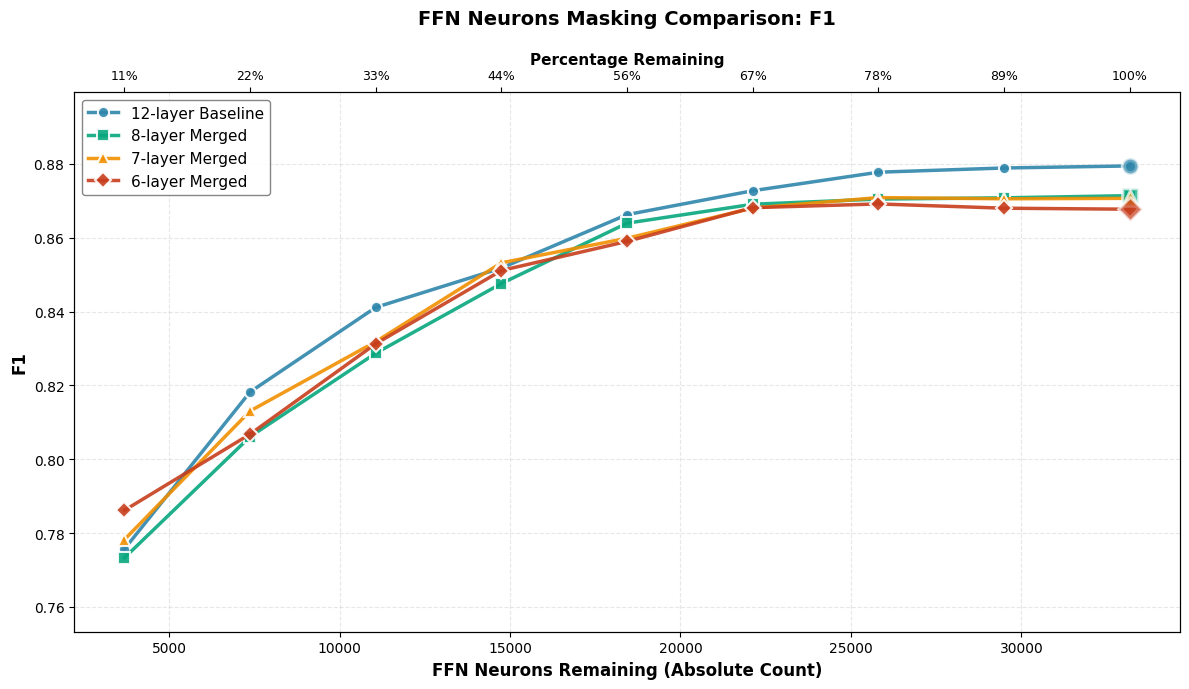

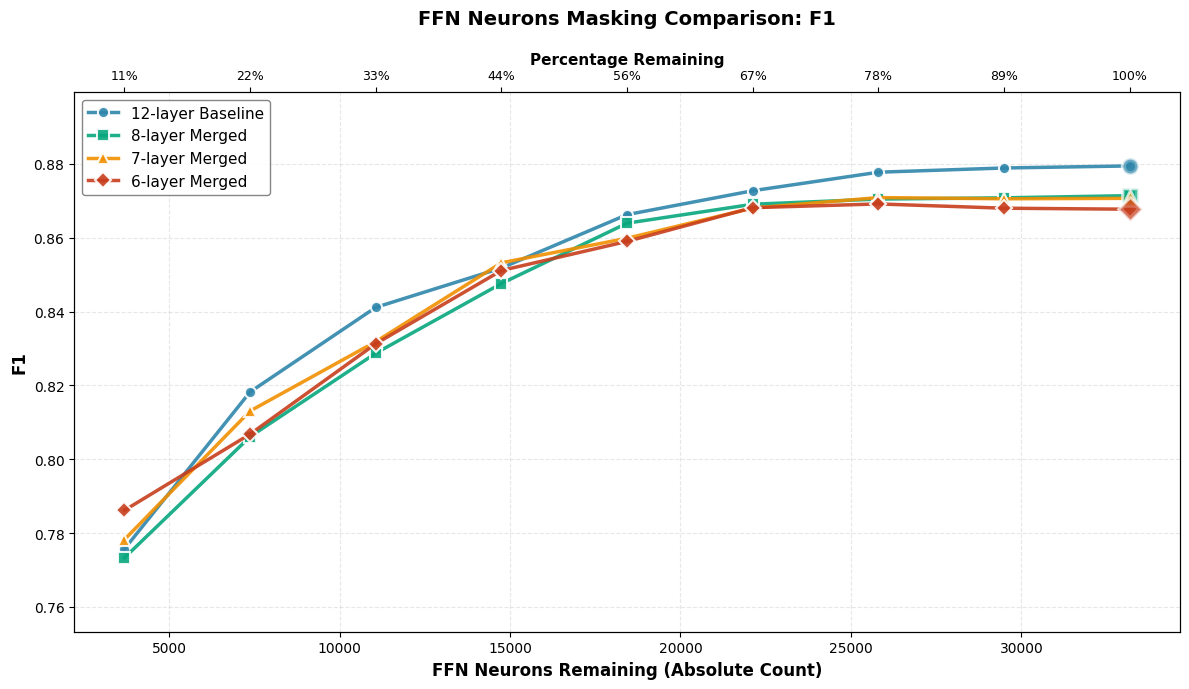

In [97]:
plot_masking_comparison(
    [mask_history_neuron, mask_history_neuron_8, mask_history_neuron_7, mask_history_neuron_6], 
    labels=['12-layer Baseline', '8-layer Merged', '7-layer Merged', '6-layer Merged'], 
    metric='f1', component='ffn'
)